# 1. Veri Setinin Tanıtımı ve Analiz Öncesi İnceleme
### 1.1 Veri Okuma (Ham Veri)
### 1.2 Veri Setinin Genel Yapısı
### 1.3 Yapısal İnceleme
### 1.4 Satır Uzunluğu İncelemesi (Analiz Öncesi)
### 1.5 Dil ve Karakter Yapısı (Analiz Öncesi)
### 1.6 Boş / Çok Kısa Satır Oranı (Analiz Öncesi)
### 1.6.a Boş / Çok Kısa Satır Oranı – Görsel İnceleme
### 1.7 Kelime Frekansları (Ham Veri)


🔹 GEREKLİ KÜTÜPHANELER (Analiz Öncesi)


In [2]:
#1️⃣ Spark çekirdeği
from pyspark.sql import SparkSession


In [3]:
#2️⃣ Temel Spark fonksiyonları
#(İnceleme / sayma / gösterim için)
from pyspark.sql.functions import col, length


### 1.1 Veri Okuma (Ham Veri)

Bu aşamada Nutuk metni herhangi bir temizlik işlemi uygulanmadan
Apache Spark ortamına alınmıştır. Amaç, metnin ham hâliyle
analiz öncesi yapısının incelenmesidir.


In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Nutuk_Analiz_Oncesi").getOrCreate()

df = spark.read.text("C:/spark_data/Nutuk.txt")


In [5]:
df.show(3, truncate=False)


+-------------------------------------+
|value                                |
+-------------------------------------+
|Samsun’a Çıktığım Gün Genel Durum ve |
|                                     |
|Görünüş                              |
+-------------------------------------+
only showing top 3 rows



### 1.2 Veri Doğrulama

Bu aşamada veri setinin Nutuk metnine ait olduğu,
metin içerisinden seçilen özgün bir ifade üzerinden
kontrol edilmiştir. Herhangi bir temizlik işlemi uygulanmamıştır.


In [5]:
df.filter(df.value.contains("Ey Türk")).show(5, truncate=False)


+----------------------------------------------+
|value                                         |
+----------------------------------------------+
|“Ey Türk Gençliği! Birinci vazifen, Türk      |
|Ey Türk geleceğinin evlâdı! İşte, bu durum ve |
+----------------------------------------------+



### 1.3 Yapısal İnceleme

Bu aşamada Nutuk metninin satır ve sütun yapısı,
veri tipi ve şeması incelenmiştir.
Herhangi bir temizlik veya filtreleme yapılmamıştır.


In [6]:
print("Satır sayısı:", df.frekans())
print("Sütun sayısı:", len(df.columns))
df.printSchema()


Satır sayısı: 42889
Sütun sayısı: 1
root
 |-- value: string (nullable = true)



### 1.4 Satır Uzunluğu İncelemesi

Bu aşamada Nutuk metnindeki satırların karakter uzunlukları
incelenmiştir. Amaç, metnin yapısal çeşitliliğini görmek olup
herhangi bir temizlik veya eleme işlemi yapılmamıştır.


In [7]:
from pyspark.sql.functions import col, length

df.select(
    length(col("value")).alias("satir_uzunlugu")
).summary().show()


+-------+------------------+
|summary|    satir_uzunlugu|
+-------+------------------+
|  count|             42889|
|   mean| 30.40339014665765|
| stddev|19.491799189967477|
|    min|                 0|
|    25%|                 0|
|    50%|                41|
|    75%|                45|
|    max|                56|
+-------+------------------+



### 1.5 Dil ve Karakter Yapısı (Analiz Öncesi)

Bu aşamada Nutuk metninde Türkçe karakterlerin ve özel sembollerin
varlığı gözlemlenmiştir. Amaç, metnin dil yapısını tanımak olup
herhangi bir temizlik veya eleme işlemi yapılmamıştır.

**Bu neyi gösterir?**
Metinde Türkçe karakter içeren satır sayısını

Dil yapısının Türkçe’ye uygun olduğunu doğrular


In [8]:
from pyspark.sql.functions import col

df.filter(
    col("value").rlike(r"[çğıöşüÇĞİÖŞÜ]")
).frekans()


29798

### 1.6 Boş / Çok Kısa Satır Oranı (Analiz Öncesi)

Bu adımda Nutuk metninde analizi bozabilecek çok kısa satırların oranı
incelenmiştir. Bu aşamada herhangi bir silme/temizlik yapılmamış, yalnızca
mevcut durum ölçülmüştür.

Tanım:
30 karakterden kısa satırlar çok kısa satır olarak kabul edilmiştir.

Amaç:
Metindeki gürültü seviyesini görmek ve temizlik gerekip gerekmediğine karar vermek.

**Bu neyi gösterir?**

Oran düşükse → metin analiz için uygundur
.
Oran yüksekse → temizlik gerekebilir.

### 1.6.a Satır Uzunluğu Kategorileri – Yüzde Dağılımı (Analiz Öncesi)

Amaç:
Satırların yüzdesel olarak hangi grupta yoğunlaştığını görmek.
(Gözle “normal mi, gürültü mü?” kararını netleştirmek

**Bu grafikte neye bakılır?**

- Normal satırların yüzdesi
- Çok kısa satırların yüzdesi
- Çok uzun satırların yüzdesi


In [24]:
# ===============================
# Satır Uzunluğu Analizi (df) Ham Veri
# ===============================
from pyspark.sql.functions import split, explode, col
from pyspark.sql.functions import length, col,trim
import matplotlib.pyplot as plt
from pyspark.sql.functions import explode
from pyspark.ml.feature import NGram
# Sayılar
toplam = df.frekans()
kisa = df.filter(length(col("value")) < 30).frekans()
normal = df.filter((length(col("value")) >= 30) & (length(col("value")) <= 80)).frekans()
uzun = df.filter(length(col("value")) > 80).frekans()

# Yüzdeye çevir
yuzdeler = [
    (kisa / toplam) * 100,
    (normal / toplam) * 100,
    (uzun / toplam) * 100
]
ngram_input = df.select(split(col("value"), " ").alias("words"))

bigram = NGram(n=2, inputCol="words", outputCol="bigrams")
bigrams_df = bigram.transform(ngram_input)
bigram_freq = (
    bigrams_df
    .select(explode(col("bigrams")).alias("ngram"))
    .groupBy("ngram")
    .frekans()
    .orderBy(col("frekans").desc())
)
top15 = bigram_freq.limit(15).collect()
etiketler = [r["ngram"] for r in top15]
degerler  = [int(r["frekans"]) for r in top15]  
etiketler = ["Çok kısa", "Normal", "Çok uzun"]




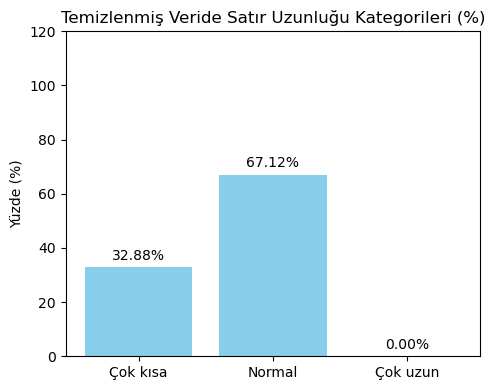

In [21]:
plt.figure(figsize=(5, 4))
cubuklar = plt.bar(etiketler, yuzdeler)
plt.ylabel("Yüzde (%)")
plt.title("Temizlenmemiş Veride Satır Uzunluğu Kategorileri (%)")
plt.ylim(0, 120)
cubuklar = plt.bar(etiketler, yuzdeler, color='skyblue')
plt.bar_label(cubuklar, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

In [29]:
# ===============================
# Satır Uzunluğu Analizi (df_clean) TemizlenmişVeri
# ===============================

from pyspark.sql.functions import col, length,trim
import matplotlib.pyplot as plt

# --- Sayılar ---
df_clean = df.filter(
    (trim(col("value")) != "") &
    (length(col("value")) > 20)
)
toplam = df_clean.frekans()

kisa = df_clean.filter(length(col("value")) < 30).frekans()
normal = df_clean.filter(
    (length(col("value")) >= 30) & (length(col("value")) <= 80)
).frekans()
uzun = df_clean.filter(length(col("value")) > 80).frekans()

# --- Yüzdeler ---
yuzdeler = [
    (kisa / toplam) * 100,
    (normal / toplam) * 100,
    (uzun / toplam) * 100
]

etiketler = ["Çok kısa (<30)", "Normal (30–80)", "Çok uzun (>80)"]

# --- Yazdırma ---
import pandas as pd

# Tablo oluştur
sonuc_tablo = pd.DataFrame({
    "Kategori": ["Çok kısa (<30)", "Normal (30–80)", "Çok uzun (>80)"],
    "Satır Sayısı": [kisa, normal, uzun],
    "Yüzde (%)": [round(y, 2) for y in yuzdeler]
})

# Tabloyu göster
sonuc_tablo



,Kategori,Satır Sayısı,Yüzde (%)
0,Çok kısa (<30),1170,3.91
1,Normal (30–80),28785,96.09
2,Çok uzun (>80),0,0.00


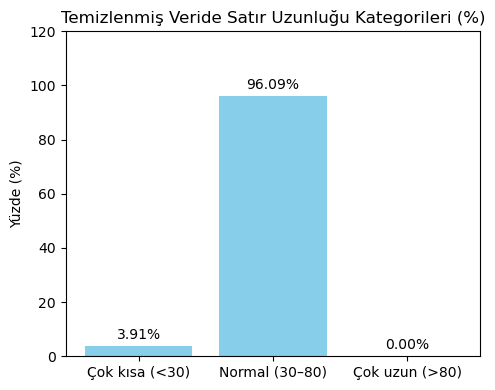

In [30]:
# GRAFİK (temizlenmiş veri)
plt.figure(figsize=(5, 4))
cubuklar = plt.bar(etiketler, yuzdeler, color="skyblue")
plt.ylabel("Yüzde (%)")
plt.title("Temizlenmiş Veride Satır Uzunluğu Kategorileri (%)")
plt.ylim(0, 120)
plt.bar_label(cubuklar, fmt="%.2f%%", padding=3)
plt.tight_layout()
plt.show()


### 1.7 Kelime Frekansları (Ham Veri)

Bu adımda Nutuk metninde geçen kelimelerin frekansları,
herhangi bir temizlik veya eleme yapılmadan incelenir.

Amaç:
- Metinde en sık geçen kelimeleri görmek
- Ham veride tekrar yapısını gözlemlemek


In [35]:
from pyspark.sql.functions import explode, split, lower, col

# metni kelimelere ayır (ham veri)
words = (
    df_clean
    .select(explode(split(lower(col("value")), r"\s+")).alias("kelime"))
)

# kelime frekansları
word_freq = (
    words
    .groupBy("kelime")
    .frekans()
    .withColumnRenamed("frekans", "frekans")
    .orderBy(col("frekans").desc())
)

# ilk 10 kelime
word_freq.show(11, truncate=False)


+----------+-------+
|kelime    |frekans|
+----------+-------+
|          |29955  |
|ve        |6504   |
|bir       |3902   |
|bu        |2799   |
|de        |926    |
|ile       |917    |
|da        |838    |
|için      |772    |
|olan      |747    |
|olarak    |666    |
|efendiler,|622    |
+----------+-------+
only showing top 11 rows



# 2. Veri Temizleme ve Metin Analitiği Hazırlığı

Bu bölümde Nutuk metni üzerinde metin analitiğine geçiş için
gerekli hazırlık adımları ele alınacaktır. Temizlik işlemleri,
önceki bölümde elde edilen analiz öncesi bulgulara dayanarak
kademeli şekilde uygulanacaktır.

**
### 2.1 Temizlik Kapsamının Tanımlanması
### 2.2 Boş ve Çok Kısa Satırların Ele Alınması
### 2.3 Metnin Analize Hazır Hale Getirilmesi
**


## 2.1 Temizlik Kapsamının Tanımlanması

Bu aşamada Nutuk metni üzerinde uygulanacak temizlik adımlarının
kapsamı belirlenmiştir. Analiz öncesi incelemeler doğrultusunda,
yalnızca boş ve çok kısa satırların elenmesine karar verilmiştir.
İçerik temelli herhangi bir silme işlemi bu aşamada yapılmamıştır.

**Bu neyi yapar?**

Boş satırları eler

Çok kısa (20 karakterden kısa) satırları eler

İçeriğe dokunmaz


In [36]:
from pyspark.sql.functions import col, trim, length

df_clean = df.filter(
    (trim(col("value")) != "") &
    (length(col("value")) > 20)
)
df_clean.show(5, truncate=False)


+----------------------------------------------+
|value                                         |
+----------------------------------------------+
|Samsun’a Çıktığım Gün Genel Durum ve          |
|1919 yılı Mayısının Ondokuzuncu Günü          |
|Samsun’a Çıktım. Ülkenin Genel Durumu ve      |
|Görünüşü Şöyleydi: Osmanlı Devleti’nin içinde |
|bulunduğu grup, I. Dünya Savaşünda yenilmiş,  |
+----------------------------------------------+
only showing top 5 rows



In [37]:
print("Temizlik Önce :", df.frekans())
print("Temizlik Sonra:", df_clean.frekans())


Temizlik Önce : 42889
Temizlik Sonra: 29955


## 2.2 Boş ve Çok Kısa Satırların Ele Alınması

Bu aşamada, analiz öncesinde belirlenen kapsam doğrultusunda
boş satırlar ve çok kısa satırlar veri setinden çıkarılmıştır.
Amaç, metnin anlamsal bütünlüğünü bozmadan analiz kalitesini artırmaktır.


In [38]:
# önce – sonra satır sayıları
before_rows = df.frekans()
after_rows = df_clean.frekans()

print("Temizlik Önce satır sayısı :", before_rows)
print("Temizlik Sonra satır sayısı:", after_rows)

# temizlik sonrası örnek satırlar
df_clean.show(5, truncate=False)


Temizlik Önce satır sayısı : 42889
Temizlik Sonra satır sayısı: 29955
+----------------------------------------------+
|value                                         |
+----------------------------------------------+
|Samsun’a Çıktığım Gün Genel Durum ve          |
|1919 yılı Mayısının Ondokuzuncu Günü          |
|Samsun’a Çıktım. Ülkenin Genel Durumu ve      |
|Görünüşü Şöyleydi: Osmanlı Devleti’nin içinde |
|bulunduğu grup, I. Dünya Savaşünda yenilmiş,  |
+----------------------------------------------+
only showing top 5 rows



## 2.3 Metnin Analize Hazır Hale Getirilmesi

Bu aşamada temizlenmiş Nutuk metni, metin analitiği yöntemlerinin
uygulanabilmesi için analiz ortamına hazır hâle getirilmiştir.
Bu adımda herhangi bir kelime çıkarımı veya modelleme yapılmamış,
yalnızca temiz veri üzerinden kontrol sağlanmıştır.

**Bu neyi gösterir?**

Analizde kullanılacak metnin son hâlini

Metnin hâlâ string yapıda olduğunu


In [39]:
# analiz için kullanılacak temel DataFrame
df_clean.select("value").show(5, truncate=False)

# veri tipi kontrolü
df_clean.printSchema()


+----------------------------------------------+
|value                                         |
+----------------------------------------------+
|Samsun’a Çıktığım Gün Genel Durum ve          |
|1919 yılı Mayısının Ondokuzuncu Günü          |
|Samsun’a Çıktım. Ülkenin Genel Durumu ve      |
|Görünüşü Şöyleydi: Osmanlı Devleti’nin içinde |
|bulunduğu grup, I. Dünya Savaşünda yenilmiş,  |
+----------------------------------------------+
only showing top 5 rows

root
 |-- value: string (nullable = true)



# 3. Kelime Temelli Analiz (Tokenizasyon ve Frekans)
  (analiz & keşif)
Bu bölümde temizlenmiş Nutuk metni üzerinde kelime temelli
analizlere geçilmektedir. Metin, kelime düzeyinde incelenmek
üzere tokenizasyon işlemine hazırlanacaktır.

**
### 3.1 Tokenizasyon (Kelimeye Ayırma)
### 3.2 Kelime Frekanslarının Hesaplanması
### 3.3 En Sık Geçen Kelimelerin İncelenmesi
### 3.4 Kelime Frekanslarının Görsel İncelenmesi
### 3.5 Satır Uzunluğu Dağılımı
### 3.6 Satır Uzunluğuna Göre Örnek Satırlar 
### 3.7 N-gram İncelemesi (Bigram/Trigram) → kelime grupları
### 3.7.a N-gram İncelemesi (Bigram) – Ham Veri
### 3.8 Stopword Etkisi (Temizlik Öncesi/Gözlemsel) → bağlaç baskısı
### 3.9 Kelime Çeşitliliği (Unique kelime sayısı)

**

## 3.1 Tokenizasyon (Kelimeye Ayırma)

Bu aşamada temizlenmiş Nutuk metni kelime düzeyinde analiz
edilebilmesi için tokenizasyon işlemine tabi tutulmuştur.
Herhangi bir kelime çıkarımı veya filtreleme yapılmamıştır.
    
**Bu neyi gösterir?**
Metnin kelimelere ayrıldığını
Her satırda tek kelime olacak şekilde yapılandığını


In [97]:
from pyspark.sql.functions import split, explode, col
df_clean = df.filter(
    (trim(col("value")) != "") &
    (length(col("value")) > 20)
)
# kelimeye ayırma
words_df = df_clean.select(
    explode(split(col("value"), " ")).alias("kelime")
)

# kontrol
words_df.show(15, truncate=False)


+-----------+
|kelime     |
+-----------+
|Samsun’a   |
|Çıktığım   |
|Gün        |
|Genel      |
|Durum      |
|ve         |
|           |
|1919       |
|yılı       |
|Mayısının  |
|Ondokuzuncu|
|Günü       |
|           |
|Samsun’a   |
|Çıktım.    |
+-----------+
only showing top 15 rows



## 3.2 Kelime Frekanslarının Hesaplanması

Bu aşamada tokenizasyon sonucunda elde edilen kelimelerin
veri seti içerisinde kaç kez tekrar ettiği hesaplanmıştır.
Amaç, metindeki kelime dağılımını nicel olarak incelemektir.

**Bu neyi gösterir?**

Her kelimenin metin içinde kaç kez geçtiğini

En sık kullanılan kelimeleri


In [96]:
# temizlenmiş kelime frekansları (stopword çıkarılmadı)

word_freq = (
    words
    .groupBy("kelime")
    .count()                           # ❗ frekans burada hesaplanır
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)

# ilk 15 kelime
word_freq.show(15, truncate=False)


+----------+-------+
|kelime    |frekans|
+----------+-------+
|          |29955  |
|ve        |6504   |
|bir       |3902   |
|bu        |2799   |
|de        |926    |
|ile       |917    |
|da        |838    |
|için      |772    |
|olan      |747    |
|olarak    |666    |
|efendiler,|622    |
|millî     |607    |
|paşa      |582    |
|bütün     |580    |
|daha      |546    |
+----------+-------+
only showing top 15 rows



## 3.3 En Sık Geçen Kelimelerin İncelenmesi

Bu aşamada kelime frekansları kullanılarak metinde en sık
tekrar eden kelimeler incelenmiştir. Amaç, Nutuk metninin
temel kelime yapısını ve baskın sözcüklerini gözlemlemektir.

**Bu neyi gösterir?**

Metinde baskın kelimeleri

Kelime dağılımının genel karakterini

In [95]:
# en sık geçen ilk 15 kelime
word_freq.select("kelime", "frekans").show(15, truncate=False)


+----------+-------+
|kelime    |frekans|
+----------+-------+
|          |29955  |
|ve        |6504   |
|bir       |3902   |
|bu        |2799   |
|de        |926    |
|ile       |917    |
|da        |838    |
|için      |772    |
|olan      |747    |
|olarak    |666    |
|efendiler,|622    |
|millî     |607    |
|paşa      |582    |
|bütün     |580    |
|daha      |546    |
+----------+-------+
only showing top 15 rows



## 3.4 Kelime Frekanslarının Görsel İncelenmesi

Bu aşamada Nutuk metninde en sık geçen kelimeler
kelime frekansları kullanılarak görsel olarak
incelenmiştir. Amaç, metindeki baskın sözcükleri
daha anlaşılır biçimde sunmaktır.


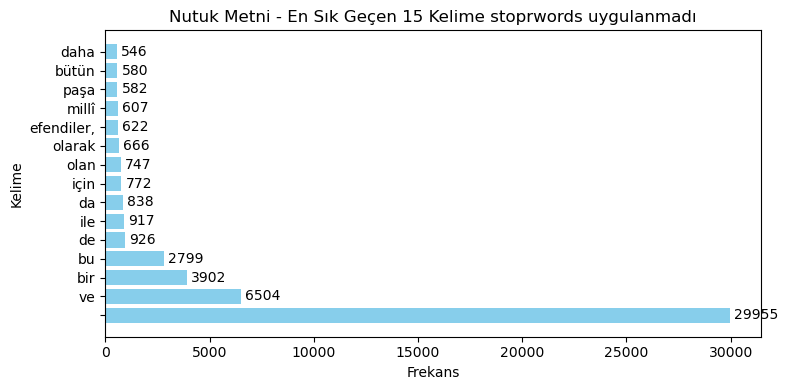

In [93]:
import matplotlib.pyplot as plt

# ilk 15 kelimeyi al
top15 = word_freq.limit(15).collect()

kelimeler = [row["kelime"] for row in top15]
sayilar = [row["frekans"] for row in top15]

plt.figure(figsize=(8,4))
cubuklar = plt.barh(kelimeler, sayilar, color='skyblue')  # # ◆ yatay çubuk-- temizlenmiş verigrafik
plt.title("Nutuk Metni - En Sık Geçen 15 Kelime stoprwords uygulanmadı")
plt.xlabel("Frekans")
plt.ylabel("Kelime")

# Frekans değerlerini ekleme
plt.bar_label(cubuklar, padding=3)

plt.tight_layout()
plt.show()

## 3.5 Satır Uzunluğu Dağılımı

Bu aşamada Nutuk metnindeki satırların karakter uzunluklarının
dağılımı görsel olarak incelenmiştir. Amaç, metnin yapısal
çeşitliliğini ortaya koymaktır.


In [85]:
import pandas as pd
import matplotlib.pyplot as plt

pd.__version__


'2.3.3'

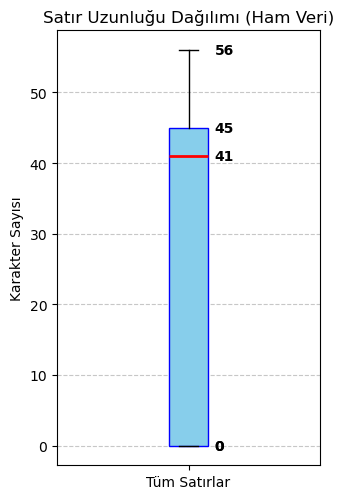

In [86]:
from pyspark.sql.functions import length, col
import matplotlib.pyplot as plt

# Ham veriden satır uzunluklarını al
lengths_pd = (
    df.select(length(col("value")).alias("len"))
      .toPandas()
)

# İstatistikler
stats = lengths_pd["len"].describe()
v = [stats['min'], stats['25%'], stats['50%'], stats['75%'], stats['max']]

# Grafik
plt.figure(figsize=(3.4, 5.1))

plt.boxplot(
    lengths_pd["len"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='blue'),
    medianprops=dict(color='red', linewidth=2)
)

# Değerleri yazdır
for val in v:
    plt.text(1.1, val, f'{int(val)}', va='center', fontweight='bold')

plt.title("Satır Uzunluğu Dağılımı (Ham Veri)")
plt.ylabel("Karakter Sayısı")
plt.xticks([1], ["Tüm Satırlar"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


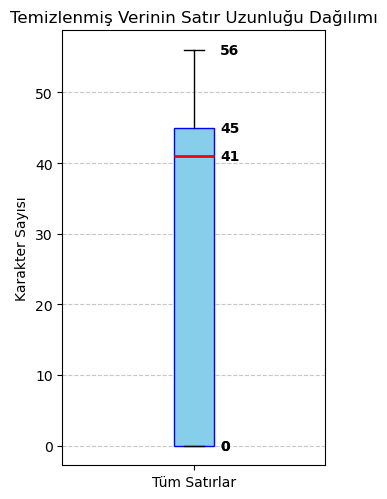

In [62]:
import matplotlib.pyplot as plt

# İstatistiksel değerleri hesapla
stats = lengths_pd["len"].describe()
v = [stats['min'], stats['25%'], stats['50%'], stats['75%'], stats['max']]

# Boyutu %15 küçültüldü (3.4, 5.1)
plt.figure(figsize=(3.4, 5.1))

# Dikey kutu grafiği
plt.boxplot(lengths_pd["len"], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))

# Değerleri yanına yazdır
for val in v:
    plt.text(1.1, val, f'{int(val)}', va='center', fontweight='bold')

plt.title("Temizlenmiş Verinin Satır Uzunluğu Dağılımı")
plt.ylabel("Karakter Sayısı")
plt.xticks([1], ["Tüm Satırlar"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3.6 Satır Uzunluğuna Göre Örnek Satırlar

In [87]:
df_len = df_clean.select("value", length(col("value")).alias("len"))

print("Kısa uzunluktaki satırlar:")
df_len.filter(col("len") < 30).show(3, False)

print("Orta uzunluktaki satırlar:")
df_len.filter((col("len") >= 40) & (col("len") <= 47)).show(3, False)

print("Uzun uzunluktaki satırlar:")
df_len.filter(col("len") > 55).show(3, False)


Kısa uzunluktaki satırlar:
+-------------------------+---+
|value                    |len|
+-------------------------+---+
|da İzmir’e çıkartılıyor. |25 |
|çökertmeye çalışıyorlar. |25 |
|kuruluşunu tamamlıyor.   |23 |
+-------------------------+---+
only showing top 3 rows

Orta uzunluktaki satırlar:
+----------------------------------------------+---+
|value                                         |len|
+----------------------------------------------+---+
|Samsun’a Çıktım. Ülkenin Genel Durumu ve      |41 |
|Görünüşü Şöyleydi: Osmanlı Devleti’nin içinde |46 |
|bulunduğu grup, I. Dünya Savaşünda yenilmiş,  |45 |
+----------------------------------------------+---+
only showing top 3 rows

Uzun uzunluktaki satırlar:
+--------------------------------------------------------+---+
|value                                                   |len|
+--------------------------------------------------------+---+
|gizlidir” kayıtlı, silâhlı millî teşkilâtlar için gizli |56 |
|biribirleriyle olan i

## 3.7 N-gram İncelemesi (Bigram / Trigram)

**Amaç**
Tek kelime yerine birlikte sık geçen kelime gruplarını (ikili–üçlü) görmek. 

**Ne gösterir?**
Metindeki kalıp ifadeleri ve söylem tekrarlarını.

In [92]:
from pyspark.sql.functions import explode
from pyspark.ml.feature import NGram
df_clean = df.filter(
    (trim(col("value")) != "") &
    (length(col("value")) > 20)
)
# kelime listesi (temizlenmiş veri varsayımı)
ngram_input = df_clean.select(split(col("value"), " ").alias("words"))

# bigram
bigram = NGram(n=2, inputCol="words", outputCol="bigrams")
bigrams_df = bigram.transform(ngram_input)

# bigram frekansları
bigram_freq = (
    bigrams_df
    .select(explode(col("bigrams")).alias("ngram"))
    .groupBy("ngram")
    .count()                               # ❗ frekans burada hesaplanır
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)

bigram_freq.show(15, truncate=False)


+------------+-------+
|ngram       |frekans|
+------------+-------+
|ve          |1249   |
|bir         |610    |
|bu          |301    |
|ile         |180    |
|Bu          |171    |
|Büyük Millet|163    |
|de          |162    |
|için        |153    |
|da          |137    |
|olan        |133    |
|olarak      |128    |
|ve bu       |122    |
|ile ilgili  |115    |
|olduğu gibi |107    |
|Paşa        |104    |
+------------+-------+
only showing top 15 rows



### 3.7.a N-gram İncelemesi (Bigram) – Ham Veri

Bu adımda Nutuk metninde en sık geçen 2’li kelime grupları (bigramlar) incelenir.
Amaç, metinde tekrar eden kelime kalıplarını gözlemlemektir.
Bu aşamada herhangi bir temizlik yapılmamıştır.

**Bu neyi gösterir?**

Metinde anlamlı kelime eşleşmeleri (ör. kalıp ifadeler) var mı, yok mu.

Aynı kelime grupları sürekli mi tekrar ediyor?

Anlamlı kalıplar mı, yoksa bağlaç ağırlığı mı var?

+------------+-------+
|ngram       |frekans|
+------------+-------+
|ve          |1249   |
|bir         |610    |
|bu          |301    |
|ile         |180    |
|Bu          |171    |
|Büyük Millet|163    |
|de          |162    |
|için        |153    |
|da          |137    |
|olan        |133    |
|olarak      |128    |
|ve bu       |122    |
|ile ilgili  |115    |
|olduğu gibi |107    |
|Paşa        |104    |
+------------+-------+



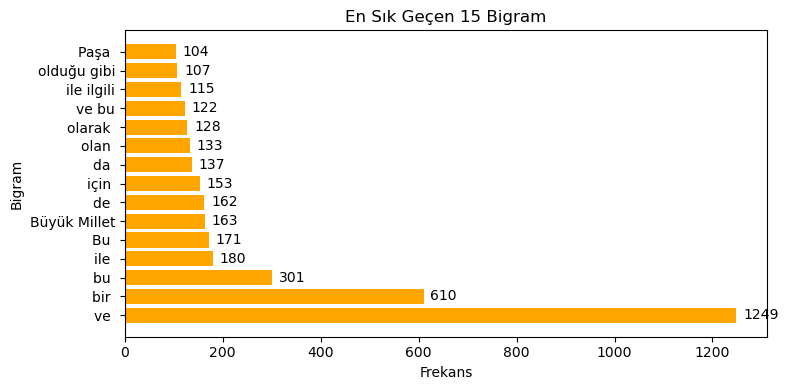

In [98]:
from pyspark.sql.functions import explode, split, col
from pyspark.ml.feature import NGram
import matplotlib.pyplot as plt

# 1) kelime listesi (df_clean)
ngram_input = df_clean.select(split(col("value"), " ").alias("words"))

# 2) bigram üret
bigram = NGram(n=2, inputCol="words", outputCol="bigrams")
bigrams_df = bigram.transform(ngram_input)

# 3) bigram frekans
# bigram frekansları
# 3) bigram frekansları
bigram_freq = (
    bigrams_df
    .select(explode(col("bigrams")).alias("ngram"))
    .groupBy("ngram")
    .count()                              # ← frekans burada hesaplanır
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)

# 4) TOP 15
top15 = bigram_freq.limit(15)
top15.show(truncate=False)


# 4) TOP 15'i al (ÖNEMLİ: burada etiket/değer aynı uzunlukta oluşur)
top15 = bigram_freq.limit(15).collect()
etiketler = [r["ngram"] for r in top15]
degerler  = [int(r["frekans"]) for r in top15]  # sayısal garanti

# 5) grafik
plt.figure(figsize=(8, 4))
cubuklar = plt.barh(etiketler, degerler, color="orange")

plt.title("En Sık Geçen 15 Bigram")
plt.xlabel("Frekans")
plt.ylabel("Bigram")

plt.bar_label(cubuklar, padding=5)

plt.tight_layout()
plt.show()


### 3.8 Stopword Etkisi (Temizlik Öncesi / Gözlemsel)  → bağlaç baskısı

**Amaç:**
Temizlik yapılmadan önce metindeki bağlaç ve stopword baskısını gözlemlemek.
Bu bölümün amacı silmek değil,
“Temizlik yapmazsam analiz ne kadar anlam kaybeder?” sorusuna cevap vermektir.

**Neye bakılır?**
En sık geçen kelimelerin stopword olup olmadığı
Frekans listesinin anlamlı kelimeler mi yoksa bağlaçlar mı ürettiği
Gözlemsel çıkarım (kendin için):
“ve, bir, bu, ile, de” gibi kelimeler üst sıralardaysa
→ stopword etkisi yüksektir

Bu durum, vektörleştirme ve TF-IDF öncesi temizlik gereğini gösterir

##En yüksek frekanslı kelimelerin tamamı bağlaç / işlev kelimesi

##Anlam taşıyan içerik kelimeleri üst sıralarda yok

##Frekans dağılımı stopword’ler tarafından baskılanıyor

**Sonuç :**
Temizlik yapılmadan kelime frekansları anlamsal bilgi üretmiyor →
Stopword temizliği zorunlu.

In [99]:
from pyspark.sql.functions import col

# örnek stopword listesi (gözlemsel)
stopwords_tr = ["ve", "bir", "bu", "ile", "de", "da", "için", "olan", "olarak"]

# stopword geçen kelimeler
stopword_freq = (
    word_freq
    .filter(col("kelime").isin(stopwords_tr))
)

stopword_freq.show(truncate=False)


+------+-------+
|kelime|frekans|
+------+-------+
|ve    |6504   |
|bir   |3902   |
|bu    |2799   |
|de    |926    |
|ile   |917    |
|da    |838    |
|için  |772    |
|olan  |747    |
|olarak|666    |
+------+-------+



In [169]:
from pyspark.sql.functions import col, split, lower, explode
from pyspark.ml.feature import StopWordsRemover

# 1️⃣ Metni kelime dizisine ayır
words_df = df_clean.select(
    split(lower(col("value")), " ").alias("words")
)

# 2️⃣ Türkçe stopwords
turkish_stopwords = [
    "ve","bir","bu","de","da","ile","için","olan","olarak",
    "ama","ancak","çok","daha","en","gibi","her","kadar",
    "mi","mu","mü","mı"
]

# 3️⃣ Stopwords temizliği
remover = StopWordsRemover(
    inputCol="words",
    outputCol="clean_words",
    stopWords=turkish_stopwords
)

clean_words_df = remover.transform(words_df)

# 4️⃣ Kelimeleri satırlara aç
words_exploded = clean_words_df.select(
    explode(col("clean_words")).alias("kelime")
)

# 5️⃣ Kelime frekansı
word_freq = (
    words_exploded
    .groupBy("kelime")
    .count()
    .orderBy(col("count").desc())
)
word_freq_renamed = word_freq.withColumnRenamed("count", "frekans")

word_freq_renamed.show(10, truncate=False)


+----------+-------+
|kelime    |frekans|
+----------+-------+
|          |29955  |
|efendiler,|622    |
|millî     |607    |
|paşa      |582    |
|bütün     |580    |
|büyük     |443    |
|bey       |403    |
|o         |393    |
|karşı     |387    |
|ne        |386    |
+----------+-------+
only showing top 10 rows



### 3.9 Kelime Çeşitliliği (Unique Kelime Sayısı)

Bu adımda Nutuk metnindeki toplam kelime sayısı ile benzersiz (unique) kelime sayısı hesaplanır.
Amaç, metnin sözcük tekrar yoğunluğunu ve çeşitlilik seviyesini gözlemlemektir.

**Bu neyi gösterir?**

Kelime çeşitliliğinin düşük/yüksek olması

Metnin tekrar ağırlıklı mı, zengin mi olduğu

Stopword temizliğinin neden gerekli olduğuna dair nicel kanıt

**Gözlemsel Not:**

Unique oranı düşüktür → tekrar fazladır

Stopword’ler çeşitlilik oranını yapay olarak düşürür

Temizlik sonrası bu oran anlamlı biçimde artmalıdır

In [103]:
from pyspark.sql.functions import countDistinct

# toplam kelime sayısı
toplam_kelime = words.count()

# benzersiz kelime sayısı
unique_kelime = words.select(countDistinct("kelime")).collect()[0][0]

# çeşitlilik oranı
cesitlilik_orani = (unique_kelime / toplam_kelime) * 100

print("Toplam kelime sayısı      :", toplam_kelime)
print("Benzersiz kelime sayısı   :", unique_kelime)
print("Kelime çeşitliliği (%)    :", round(cesitlilik_orani, 2))


Toplam kelime sayısı      : 193297
Benzersiz kelime sayısı   : 33422
Kelime çeşitliliği (%)    : 17.29


# 4. Vektörleştirme (frekansVectorizer)

Bu bölümde Nutuk metni kelime frekanslarına dayalı olarak
sayısal vektörlere dönüştürülmüştür. Amaç, metnin makine
öğrenmesi ve ileri metin analitiği yöntemlerine uygun
bir temsile kavuşturulmasıdır.


## 4.1 frekansVectorizer Uygulaması

Bu aşamada metin, kelime sıklıklarını temel alan
frekansVectorizer yöntemi ile sayısal vektörlere dönüştürülmüştür.
Her kelime bir özellik (feature) olarak temsil edilmiştir.

**Bu neyi gösterir?**

Metnin sayısal vektörlere dönüştürüldüğünü

Her satırın kelime-frekans temsiline sahip olduğunu

**sonuç:**
frekansVectorizer yöntemi ile metin, 35.920 kelimelik bir sözlük üzerinden sayısal vektörlere dönüştürülmüştür.
Her satır, yalnızca o satırda geçen kelimelerin indekslerini ve bu kelimelerin frekanslarını içeren seyrek (sparse) bir vektör ile temsil edilmektedir.
İncelenen örnek satırda yer alan kelimelerin frekansı 1’dir.

In [107]:
from pyspark.ml.feature import CountVectorizer

# metni kelime listesi formatına getir
cv_input = df_clean.select(
    split(col("value"), " ").alias("words")
)

# frekansVectorizer
cv = CountVectorizer(inputCol="words", outputCol="rawFeatures")
cv_model = cv.fit(cv_input)
cv_df = cv_model.transform(cv_input)

# kontrol
cv_df.select("rawFeatures").show(5, truncate=False)


+------------------------------------------------------------------------+
|rawFeatures                                                             |
+------------------------------------------------------------------------+
|(35875,[0,1,192,1680,2841,26161,31020],[1.0,1.0,1.0,1.0,1.0,1.0,1.0])   |
|(35875,[0,88,997,7558,16150,21627],[1.0,1.0,1.0,1.0,1.0,1.0])           |
|(35875,[0,1,192,1680,2180,26425,27097],[1.0,1.0,1.0,1.0,1.0,1.0,1.0])   |
|(35875,[0,53,111,520,14477,34812],[1.0,1.0,1.0,1.0,1.0,1.0])            |
|(35875,[0,245,1328,3756,7386,17295,27329],[1.0,1.0,1.0,1.0,1.0,1.0,1.0])|
+------------------------------------------------------------------------+
only showing top 5 rows



### 4.2 TF-IDF (Terim Ağırlıklandırma)

**Amaç:**
frekansVectorizer ile elde edilen kelime-frekans vektörlerinde, metin için ayırt edici kelimeleri öne çıkarmak.

**Ne farkı var?**

frekansVectorizer → kaç kez geçti

TF-IDF → ne kadar ayırt edici

**Bu çıktıda ne görüyorsun?**

Her satır artık TF-IDF ağırlıklı vektör

Sık ama anlamsız kelimelerin etkisi azalır

Metne özgü kelimelerin etkisi artar

In [108]:
from pyspark.ml.feature import IDF

# TF-IDF modeli
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(cv_df)
tfidf_df = idf_model.transform(cv_df)

# kontrol
tfidf_df.select("features").show(5, truncate=False)


+------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                    |
+------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(35875,[0,1,192,1680,2841,26161,31020],[0.0,1.5711561960363494,5.774885424216002,7.599434716267048,8.110260340033038,9.614337736809313,9.614337736809313])  |
|(35875,[0,88,997,7558,16150,21627],[0.0,5.283604396522981,7.171990701440108,8.921190556249368,9.614337736809313,9.614337736809313])                         |
|(35875,[0,1,192,1680,2180,26425,27097],[0.0,1.5711561960363494,5.774885424216002,7.599434716267048,7.909589644570887,9.614337736809313,9.614337736809313])  |
|(35875,[0,53,111,520,14477,34812],[0.0,4.9893

# 5. Veri Temizleme

Bu bölümde, analiz öncesi incelemeler sonucunda belirlenen gürültü unsurları veri setinden fiilen kaldırılır.
### 5. Veri Temizleme
### 5.1 Çok Kısa Satırların Kaldırılması
### 5.2 Metin Temizleme ve Stopword’lerin Çıkarılması
### 5.3 Temizlenmiş Metnin Oluşturulması



### 5.1 Çok Kısa Satırların Kaldırılması

**Amaç:**
Analize anlamsal katkısı olmayan, çok kısa ve bağlam içermeyen satırları veri setinden çıkarmak.

**Kriter:**
Belirli bir karakter uzunluğunun altındaki satırlar gürültü olarak kabul edilir.

**Kontrol etmen gerekenler:**

Satır sayısı azaldı mı?

Mantıklı bir düşüş mü?

In [110]:
from pyspark.sql.functions import length, col

# çok kısa satırları filtrele (örnek eşik: 30 karakter)
df_len_filtered = df_clean.filter(length(col("value")) >= 30)

# kontrol
print("Temizlik öncesi satır sayısı :", df_clean.count())
print("Temizlik sonrası satır sayısı:", df_len_filtered.count())


Temizlik öncesi satır sayısı : 29955
Temizlik sonrası satır sayısı: 28785


## 5.2 Metin Temizleme ve Stopword’lerin Çıkarılması

Bu aşamada küçük harfe dönüştürme, noktalama temizliği, stopword çıkarma ve temiz metin oluşturma işlemleri birlikte uygulanmıştır.
**Amaç:**
Anlamsal katkısı düşük olan bağlaç ve işlev kelimelerini (stopword) metinden çıkarmak.

**Yöntem:**
PySpark StopWordsRemover kullanılarak kelime listesi üzerinden stopword’ler temizlenir.

**Yapılan İşlemler**

- Metinler küçük harfe dönüştürüldü (büyük/küçük harf farkı kaldırıldı).
- Noktalama işaretleri ve özel karakterler temizlendi.
- Metinler kelimelere ayrıldı.
- Türkçe stopword’ler (ve, bir, bu, ile vb.) çıkarıldı.
- Analize hazır, temiz kelime listeleri (`words_clean`) elde edildi.
- Çıktılar satır araları çizgilerle ayrılarak okunabilir hale getirildi.


In [111]:
from pyspark.sql.functions import split, col, lower, regexp_replace
from pyspark.ml.feature import StopWordsRemover

# 1) Metni temizle ve kelimelere ayır
words_df = df_clean.select(
    split(                                  # metni boşluklardan böl
        lower(                              # tüm harfleri küçült
            regexp_replace(                # noktalama ve özel karakterleri sil
                col("value"),
                "[^a-zA-ZçğıöşüÇĞİÖŞÜ0-9 ]",
                ""
            )
        ),
        " "
    ).alias("words")                        # kelime listesi oluştur
)

# 2) Türkçe stopword listesi
turkish_stopwords = [
    "ve", "bir", "bu", "da", "de", "ile", "için", "olarak",
    "olan", "gibi", "daha", "kadar", "her", "mi"
]

# 3) Stopword temizleme
remover = StopWordsRemover(
    inputCol="words",                      # giriş: kelime listesi
    outputCol="words_clean",               # çıkış: temiz kelimeler
    stopWords=turkish_stopwords
)

words_clean_df = remover.transform(words_df)  # stopword’ler çıkarılır

# 4) Ayracı olan örnek çıktı (ilk 5 satır)
rows = words_clean_df.select("words_clean").take(5)

for row in rows:
    print("KELİMELER :", row["words_clean"])
    print("-" * 50)                         # satır ayırıcı


KELİMELER : ['samsuna', 'çıktığım', 'gün', 'genel', 'durum', '']
--------------------------------------------------
KELİMELER : ['1919', 'yılı', 'mayısının', 'ondokuzuncu', 'günü', '']
--------------------------------------------------
KELİMELER : ['samsuna', 'çıktım', 'ülkenin', 'genel', 'durumu', '']
--------------------------------------------------
KELİMELER : ['görünüşü', 'şöyleydi', 'osmanlı', 'devletinin', 'içinde', '']
--------------------------------------------------
KELİMELER : ['bulunduğu', 'grup', 'ı', 'dünya', 'savaşünda', 'yenilmiş', '']
--------------------------------------------------


## 5.3 Temizlenmiş Metnin Oluşturulması

Bu adımda stopword’leri çıkarılmış kelime listeleri tekrar metin
formatına dönüştürülmüştür.

**Amaç:**
- Analize hazır, temiz metin elde etmek
- TF, TF-IDF gibi yöntemlerde doğrudan kullanılabilir yapı oluşturmak

**Yapılan İşlemler**
- Stopword’leri çıkarılmış kelime listeleri tekrar metne dönüştürüldü  
- Her satır temizlenmiş tek bir metin haline getirildi




In [112]:
from pyspark.sql.functions import concat_ws, col

# Kelime listelerini tekrar metne çevir
clean_text_df = words_clean_df.select(
    concat_ws(" ", col("words_clean")).alias("clean_text")
    # words_clean listesini boşlukla birleştir → temiz metin
)

# ----’li çıktı kuralı (okunabilirlik)
rows = clean_text_df.select("clean_text").take(5)
# İlk 5 temizlenmiş metni al

for row in rows:
    print("METİN :", row["clean_text"])
    print("-" * 50)   # satır ayırıcı


METİN : samsuna çıktığım gün genel durum 
--------------------------------------------------
METİN : 1919 yılı mayısının ondokuzuncu günü 
--------------------------------------------------
METİN : samsuna çıktım ülkenin genel durumu 
--------------------------------------------------
METİN : görünüşü şöyleydi osmanlı devletinin içinde 
--------------------------------------------------
METİN : bulunduğu grup ı dünya savaşünda yenilmiş 
--------------------------------------------------


## 6. Kelime Frekans Analizi

**Amaç:**  
Temizlenmiş metinlerde en sık geçen kelimeleri belirleyerek metnin genel konu yapısı ve baskın kavramları hakkında ön bilgi elde etmek.

**Yöntem:**  
Temiz kelime listeleri (`words_clean`) kullanılarak kelimeler tekilleştirilmiş, her kelimenin metin boyunca tekrar sayısı hesaplanmış ve frekanslarına göre azalan biçimde sıralanmıştır.

**Yapılan İşlemler:**  
- Temizlenmiş kelime listeleri satır bazında ayrıştırıldı.  
- Kelimeler gruplanarak frekansları (`frekans`) hesaplandı.  
- En sık geçen ilk 10 kelime tablo formatında gösterildi.

**Çıktının Anlamı:**  
- **Kelime:** Metinde geçen anlamlı sözcükleri temsil eder.  
- **Frekans:**  İlgili kelimenin tüm metin boyunca kaç kez tekrarlandığını gösterir.  

Stopword’ler ve gereksiz karakterler temizlendiği için tabloda yer alan kelimeler, metnin içeriğini ve baskın temalarını yansıtmaktadır (ör. *paşa, bey, efendiler*).

**Yorum:**  
Elde edilen sonuçlarda *“paşa”*, *“bey”* ve *“efendiler”* gibi hitap ve unvan ifadelerinin öne çıkması, metnin resmî ve hitap ağırlıklı bir anlatı yapısına sahip olduğunu göstermektedir.  
Ayrıca *“mil”*, *“bütün”* ve *“büyük”* gibi kelimelerin yüksek frekansları, kolektif kimlik ve bütünlük vurgusunun metinde önemli bir yer tuttuğunu göstermektedir.


In [117]:
from pyspark.sql.functions import split, explode, col

# temiz metni tekrar kelimelere ayır
clean_words_df = clean_text_df.select(
    split(col("clean_text"), " ").alias("words")
)

# kelime frekansları
word_freq = (
    clean_words_df
    .select(explode(col("words")).alias("kelime"))
    .groupBy("kelime")
    .count()
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)

word_freq = word_freq.filter(col("kelime") != "")

# AYRAÇLI ÇIKTI (ilk 15 kelime)
# ilk 10 kelimeyi tablo olarak göster
word_freq.select(
    col("kelime").alias("Kelime"),
    col("frekans").alias("count")
).show(15, truncate=False)


+---------+-----+
|Kelime   |count|
+---------+-----+
|paşa     |930  |
|bey      |802  |
|sonra    |726  |
|efendiler|658  |
|mill     |631  |
|bütün    |587  |
|ki       |470  |
|büyük    |451  |
|karşı    |428  |
|ne       |406  |
|o        |406  |
|olduğu   |404  |
|millet   |391  |
|beyin    |389  |
|bulunan  |371  |
+---------+-----+
only showing top 15 rows



## 7. TF-IDF Analizi
**Amaç:**

Bu bölümde, yalnızca sık geçen kelimeleri değil; metni diğer metinlerden ayırt eden, ayırt ediciliği yüksek kelimeleri belirlemek amaçlanmaktadır. TF-IDF yöntemi, kelimelerin hem metin içindeki sıklığını (TF) hem de genel dağılımını (IDF) dikkate alarak daha anlamlı bir ağırlıklandırma sağlar.

**Yöntem:**

Temizlenmiş metinler (clean_text) kullanılmıştır.

Metinler yeniden kelimelere ayrılmıştır.

frekansVectorizer ile kelime frekans vektörleri (TF) oluşturulmuştur.

IDF modeli uygulanarak TF-IDF ağırlıkları hesaplanmıştır.

**Çıktının Anlamı:**

features kolonu, her satır için TF-IDF ağırlıklarını içeren sayısal vektörü temsil eder.

Vektörde sıfırdan büyük değer alan kelimeler, metin için ayırt edici öneme sahip kelimelerdir.

Bu çıktı, ileri analizler (en önemli kelimelerin çıkarılması, sınıflandırma, konu analizi vb.) için temel oluşturur.


In [183]:
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.sql.functions import split, col

# temiz metni tekrar kelimelere ayır
tf_input_df = clean_text_df.select(
    split(col("clean_text"), " ").alias("words")
)

# TF (CountVectorizer)
cv = CountVectorizer(
    inputCol="words",
    outputCol="rawFeatures"
)

cv_model = cv.fit(tf_input_df)
cv_df = cv_model.transform(tf_input_df)

# IDF
idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

idf_model = idf.fit(cv_df)
tfidf_df = idf_model.transform(cv_df)

# TF-IDF vektörlerini Python tarafına al
rows = tfidf_df.select("features").take(5)

for i, row in enumerate(rows, start=1):
    print(f"SATIR {i} - TF-IDF VEKTÖRÜ:")
    print(row["features"])
    print("-" * 50)



SATIR 1 - TF-IDF VEKTÖRÜ:
(27007,[0,43,60,77,1649,4866],[0.0,4.886949918096972,5.034485358805511,5.189491104952503,7.534896195129477,8.698047004935157])
--------------------------------------------------
SATIR 2 - TF-IDF VEKTÖRÜ:
(27007,[0,87,95,1055,9189,17339],[0.0,5.2576289101197204,5.3170523305905215,7.171990701440108,9.208872628701148,9.614337736809313])
--------------------------------------------------
SATIR 3 - TF-IDF VEKTÖRÜ:
(27007,[0,43,74,1649,2989,11489],[0.0,4.886949918096972,5.142698943445744,7.534896195129477,8.228043375689422,9.208872628701148])
--------------------------------------------------
SATIR 4 - TF-IDF VEKTÖRÜ:
(27007,[0,34,126,450,1872,7140],[0.0,4.79809658074128,5.463297830910666,6.3562411987878304,7.742535559907721,8.921190556249368])
--------------------------------------------------
SATIR 5 - TF-IDF VEKTÖRÜ:
(27007,[0,237,392,905,2355,4483,17133],[0.0,5.900765670105004,6.229947473463538,7.049388379347776,7.909589644570887,8.515725448141202,9.614337736809

## 8. Kelime Frekanslarının Görselleştirilmesi
### 8.1 En Sık Geçen Kelimeler (Çubuk Grafik)
### 8.2 Kelime Bulutu (WordCloud)

## 8. Kelime Frekanslarının Görselleştirilmesi

**Amaç:**  
Temizlenmiş metinde en sık geçen kelimelerin görsel olarak sunulması ve
metnin baskın kavramlarının daha kolay yorumlanmasını sağlamak.

**Yöntem:**  
Kelime frekans tablosu kullanılarak en yüksek frekansa sahip ilk 10 kelime seçilmiş,
Spark DataFrame Pandas’a dönüştürülerek yatay çubuk grafik oluşturulmuştur.

**Sonuç:**  
Oluşturulan grafik, metinde öne çıkan kavramları görsel olarak açık biçimde
göstermekte ve frekans analizinin yorumlanmasını kolaylaştırmaktadır.

### 8.1 En Sık Geçen Kelimeler (Çubuk Grafik)

**Amaç:**
Temizlenmiş metinde en sık geçen kelimeleri görsel olarak göstermek ve frekans dağılımını hızlıca yorumlamak.

**Bu grafik neyi gösterir?**

Metinde hangi kelimelerin baskın olduğunu

Temizlik sonrası stopword’lerin etkisinin azaldığını

Frekans farklarının görsel olarak netleştiğini

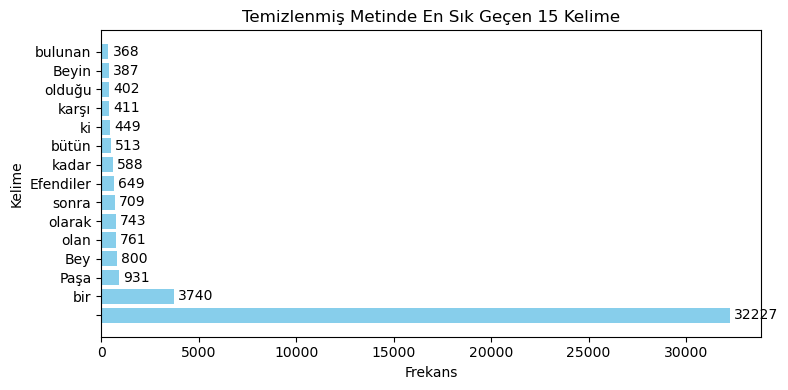

In [213]:
# Spark → Pandas
top10_df = (
    word_freq
    .limit(15)
    .toPandas()
)

# Spark count sütununu düzelt
top10_df = top10_df.rename(columns={"count": "frekans"})

# Grafik
plt.figure(figsize=(8, 4))

bars = plt.barh(
    top10_df["kelime"],
    top10_df["frekans"],
    color="skyblue"
)

plt.xlabel("Frekans")
plt.ylabel("Kelime")
plt.title("Temizlenmiş Metinde En Sık Geçen 15 Kelime")

plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()


### 8.2 Kelime Bulutu (WordCloud)

**Amaç:**  
Temizlenmiş metinde öne çıkan kelimeleri görsel yoğunluklarına göre sunarak,
metnin genel temasını ve baskın kavramlarını sezgisel biçimde ortaya koymak.

**Yöntem:**  
Kelime frekans tablosu kullanılarak her kelimenin tekrar sayısı ağırlık olarak alınmış,
WordCloud yöntemi ile görsel bir temsil oluşturulmuştur.

**Sonuç:**  
Kelime bulutu, metinde sık geçen kavramların görsel olarak daha büyük ve belirgin
şekilde gösterilmesini sağlayarak frekans analizinin yorumlanmasını desteklemektedir.


In [129]:
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable


In [130]:
import sys
!{sys.executable} -m pip install wordcloud


In [131]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [132]:
from pyspark.sql.functions import col

wc_df = (
    word_freq
    .select(
        col("kelime").alias("Kelime"),
        col("frekans").alias("Frekans")
    )
    .orderBy(col("Frekans").desc())
    .limit(100)
    .toPandas()
)

# Tablo formatında ilk 10 satır
wc_df.head(10)


,Kelime,Frekans
0,paşa,930
1,bey,802
2,sonra,726
3,efendiler,658
4,mill,631
5,bütün,587
6,ki,470
7,büyük,451
8,karşı,428
9,ne,406


In [133]:
from pyspark.sql.functions import col

# 1. Önce istediğiniz tablo formatı için sütun isimlerini güncelliyoruz
wc_df = (
    word_freq
    .select(
        col("kelime").alias("Kelime"), 
        col("frekans").alias("Frekans")
    )
    .limit(100)
    .toPandas()
)

# 2. Sözlük (freq_dict) oluştururken yeni sütun isimlerini ("Kelime" ve "Frekans") kullanıyoruz
freq_dict = dict(zip(wc_df["Kelime"], wc_df["Frekans"]))

# Sonuçları kontrol edelim
print(f"Sözlük uzunluğu: {len(freq_dict)}")
wc_df.head(10)

Sözlük uzunluğu: 100


,Kelime,Frekans
0,paşa,930
1,bey,802
2,sonra,726
3,efendiler,658
4,mill,631
5,bütün,587
6,ki,470
7,büyük,451
8,karşı,428
9,ne,406


In [134]:
import pandas as pd
from pyspark.sql.functions import col

# 1. VERİYİ HAZIRLAMA
wc_df = (
    word_freq
    .select(
        col("kelime").alias("Kelime"), 
        col("frekans").alias("Frekans")
    )
    .limit(40) 
    .toPandas()
)

# Genel Sıra Numarasını ekleyelim (1'den başlar)
wc_df.insert(0, 'Sıra No', range(1, len(wc_df) + 1))

# 2. TABLO FORMATLAMA: Veriyi yan yana iki tablo bloğu haline getirme
df1 = wc_df.iloc[:20].reset_index(drop=True)
df2 = wc_df.iloc[20:40].reset_index(drop=True)

# Yan yana birleştirilmiş tablo çıktısı
side_by_side = pd.concat([df1, df2], axis=1)

# 3. ŞIK TABLO GÖSTERİMİ VE SİYAH AYRAÇ ÇİZGİSİ
styled_table = side_by_side.style.set_caption("Sıra Numaralı Kelime Frekans Listesi (Yan Yana)") \
    .set_table_styles([
        # Genel başlık stili
        {'selector': 'th', 'props': [
            ('background-color', '#404040'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('padding', '10px 15px'),
            ('text-align', 'center'),
            ('border', '1px solid #ddd')
        ]},
        # İlk tablonun son sütun başlığına siyah sağ çizgi ekle
        {'selector': 'th.col2', 'props': [('border-right', '3px solid black')]},
        # İlk tablonun son sütun hücrelerine siyah sağ çizgi ekle
        {'selector': 'td.col2', 'props': [('border-right', '3px solid black')]},
        # Tüm hücreler için genel boşluk ve hizalama
        {'selector': 'td', 'props': [
            ('padding', '8px 20px'),
            ('text-align', 'left'),
            ('border-bottom', '1px solid #eee')
        ]}
    ]) \
    .format(precision=0) \
    .hide(axis='index') 

# Tabloyu göster
styled_table

Sıra No,Kelime,Frekans,Sıra No,Kelime,Frekans
1,paşa,930,21,bazı,304
2,bey,802,22,en,291
3,sonra,726,23,önce,290
4,efendiler,658,24,olduğunu,288
5,mill,631,25,birlikte,287
6,bütün,587,26,hükümet,286
7,ki,470,27,çok,276
8,büyük,451,28,milletin,270
9,karşı,428,29,ilgili,270
10,ne,406,30,tarafından,269


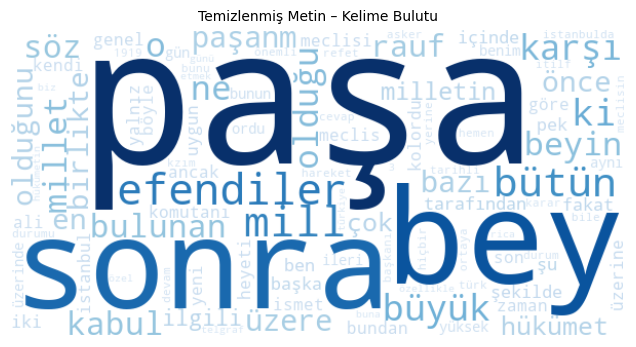

In [135]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Frekansa göre renk skalası (koyu → açık)
def freq_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    max_freq = max(freq_dict.values())
    freq = freq_dict[word]
    norm = freq / max_freq  # 1 = en yüksek frekans
    r, g, b, _ = cm.Blues(norm)  # koyu mavi → açık mavi
    return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

wordcloud = WordCloud(
    width=600,
    height=300,
    background_color="white",
    collocations=False,
    color_func=freq_color_func
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Temizlenmiş Metin – Kelime Bulutu", fontsize=10)
plt.show()


# 9.Temizlenmiş   ve dengelenmiş veri ile çalışma

### Ham veriden “Temizlenmiş + Stopword + Dengelenmiş” yeni veri seti oluşturuldu

In [226]:
from pyspark.sql.functions import regexp_replace, lower


In [227]:
df_balanced = df_balanced.withColumn(
    "value",
    regexp_replace(col("value"), "[^a-zA-ZçğıöşüÇĞİÖŞÜ ]", "")
)


In [240]:


from pyspark.sql.functions import col, trim, length, split, concat_ws
from pyspark.ml.feature import StopWordsRemover

from pyspark.sql.functions import regexp_replace


# 1.1 Boş ve çok kısa satırları kaldır
df_clean = df.filter(
    (trim(col("value")) != "") &
    (length(col("value")) > 20)
)

# 1.2 Kelimelere ayır
words_df = df_clean.select(
    split(col("value"), " ").alias("words")
)

# 1.3 Türkçe stopwords kaldır
remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=StopWordsRemover.loadDefaultStopWords("turkish")
)
df_nostop = remover.transform(words_df)

# 1.4 Kelimeleri tekrar metne çevir (temizlenmiş + stopword sonrası metin)
df_final = df_nostop.select(
    concat_ws(" ", col("filtered_words")).alias("value")
)

# 1.5 DENGELEME: 30–80 karakter aralığı
df_balanced = df_final.filter(
    (length(col("value")) >= 30) &
    (length(col("value")) <= 80)
)


from pyspark.sql.functions import explode, split, col

# SATIR SAYILARI (kaç metin var)
print("df (ham veri) satır sayısı:", df.count())
print("df_clean (temizlenmiş) satır sayısı:", df_clean.count())
print("df_final (stopword sonrası) satır sayısı:", df_final.count())
print("Dengelenmiş veri seti (30–80 karakter):", df_balanced.count())


# KELİME SAYISI (toplam token sayısı)
kelime_sayisi = (
    df_balanced
    .select(explode(split(col("value"), " ")).alias("kelime"))
    .filter(col("kelime") != "")
    .count()
)

print("Dengelenmiş veri seti toplam kelime sayısı:", kelime_sayisi)


df (ham veri) satır sayısı: 42889
df_clean (temizlenmiş) satır sayısı: 29955
df_final (stopword sonrası) satır sayısı: 29955
Dengelenmiş veri seti (30–80 karakter): 28304
Dengelenmiş veri seti toplam kelime sayısı: 140933


In [241]:
df_balanced = df_balanced.withColumn(
    "value",
    regexp_replace(col("value"), "[^a-zA-ZçğıöşüÇĞİÖŞÜ ]", "")
)

In [242]:
from pyspark.sql.functions import explode, split, col

words_freq_df = (
    df_balanced
    .select(explode(split(col("value"), " ")).alias("kelime"))
    .groupBy("kelime")
    .count()
    .orderBy(col("count").desc())
)

words_freq_df.show(15)


+---------+-----+
|   kelime|count|
+---------+-----+
|         |30463|
|      bir| 3646|
|     Paşa|  901|
|      Bey|  784|
|     olan|  746|
|   olarak|  725|
|    sonra|  696|
|Efendiler|  641|
|    kadar|  576|
|    bütün|  502|
|       ki|  440|
|    karşı|  405|
|    Beyin|  382|
|   olduğu|  379|
|  bulunan|  363|
+---------+-----+
only showing top 15 rows



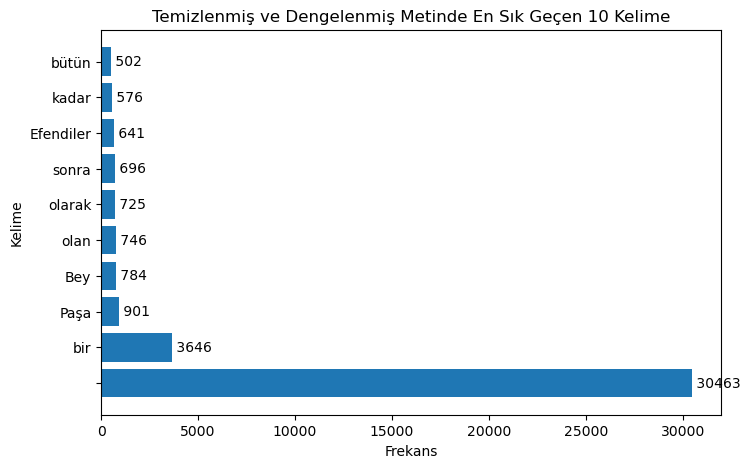

In [243]:
# Spark → Pandas
pdf = words_freq_df.limit(10).toPandas()

# Grafik
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(pdf["kelime"], pdf["count"])
plt.xlabel("Frekans")
plt.ylabel("Kelime")
plt.title("Temizlenmiş ve Dengelenmiş Metinde En Sık Geçen 10 Kelime")
# Çubukların ucuna frekans değerlerini yaz
for index, value in enumerate(pdf["count"]):
    plt.text(value, index, f" {value}", va="center")

plt.show()


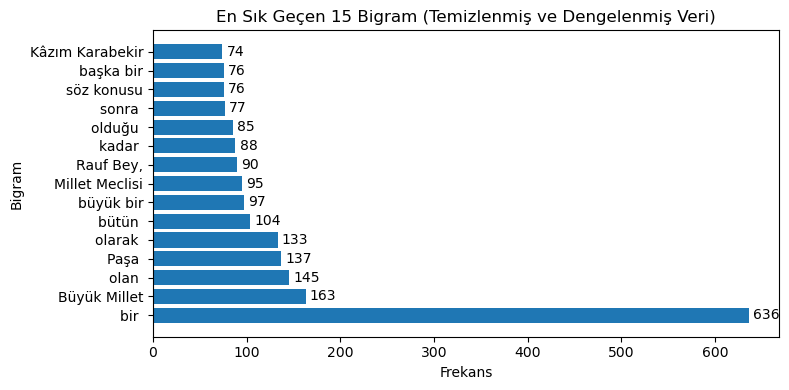

In [244]:
# 3️⃣ Bigram analizi (temizlenmiş ve dengelenmiş veri)

from pyspark.sql.functions import split, explode, col
from pyspark.ml.feature import NGram
import matplotlib.pyplot as plt

# Kelimeleri liste haline getir
ngram_input = df_final.select(
    split(col("value"), " ").alias("words")
)

# Bigram oluştur (2-kelimelik yapılar)
bigram = NGram(n=2, inputCol="words", outputCol="bigrams")
bigrams_df = bigram.transform(ngram_input)

# Bigram frekanslarını hesapla
bigram_freq = (
    bigrams_df
    .select(explode(col("bigrams")).alias("bigram"))
    .groupBy("bigram")
    .count()
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)


# En sık geçen 15 bigram
top15 = bigram_freq.limit(15).toPandas()

# Görselleştir (yatay çubuk grafik)
plt.figure(figsize=(8, 4))
bars = plt.barh(top15["bigram"], top15["frekans"])
plt.xlabel("Frekans")
plt.ylabel("Bigram")
plt.title("En Sık Geçen 15 Bigram (Temizlenmiş ve Dengelenmiş Veri)")
plt.gca().invert_yaxis()  # en büyük üstte
plt.bar_label(bars, padding=3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


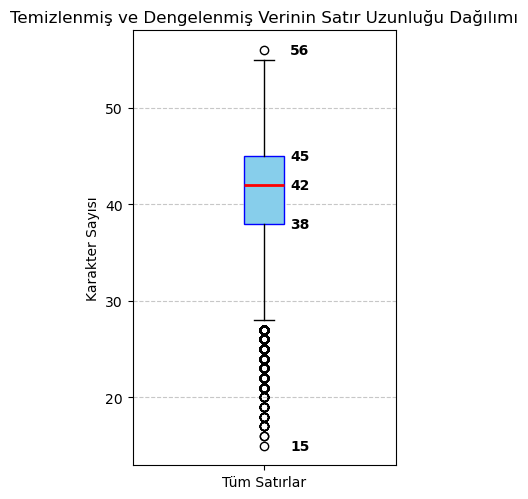

In [152]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import length, col

# 🔹 Dengelenmiş + temizlenmiş veri seti: df_final
# Satır uzunluklarını hesapla
lengths_df = df_final.select(
    length(col("value")).alias("len")
)

# Spark → Pandas
lengths_pd = lengths_df.toPandas()

# İstatistiksel değerler
stats = lengths_pd["len"].describe()
v = [
    stats["min"],
    stats["25%"],
    stats["50%"],
    stats["75%"],
    stats["max"]
]

# Boxplot
plt.figure(figsize=(3.4, 5.1))

plt.boxplot(
    lengths_pd["len"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="red", linewidth=2)
)

# Değerleri yanına yaz
for val in v:
    plt.text(1.1, val, f"{int(val)}", va="center", fontweight="bold")

plt.title("Temizlenmiş ve Dengelenmiş Verinin Satır Uzunluğu Dağılımı")
plt.ylabel("Karakter Sayısı")
plt.xticks([1], ["Tüm Satırlar"])
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()



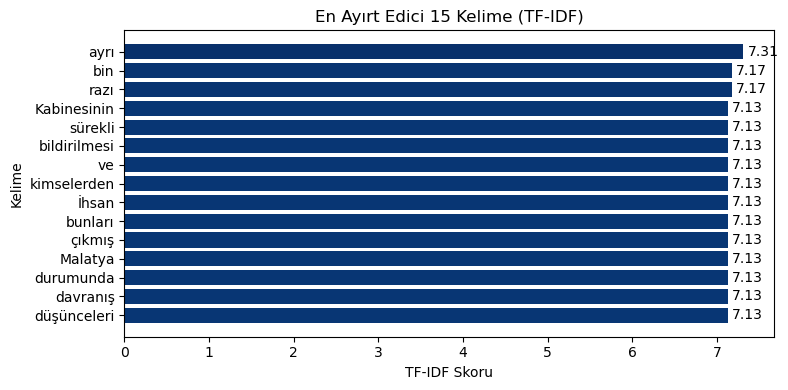

In [245]:
# 4️⃣ TF-IDF analizi (temizlenmiş + stopwords uygulanmış + dengelenmiş veri)

from pyspark.sql.functions import split, col
from pyspark.ml.feature import CountVectorizer, IDF
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql.functions import regexp_replace

df_final = df_final.withColumn(
    "value",
    regexp_replace(col("value"), "[^a-zA-ZçğıöşüÇĞİÖŞÜ ]", "")
)

# Kelime listesi
tf_input = df_final.select(
    split(col("value"), " ").alias("words")
)

# TF
cv = CountVectorizer(
    inputCol="words",
    outputCol="rawFeatures",
    vocabSize=1000,   # en fazla 1000 kelime
    minDF=5           # nadir kelimeler elenir
)
cv_model = cv.fit(tf_input)
tf_df = cv_model.transform(tf_input)

# IDF
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(tf_df)
tfidf_df = idf_model.transform(tf_df)

# Kelime–TF-IDF tablosu
vocab = cv_model.vocabulary
idf_vals = idf_model.idf.toArray()

tfidf_pd = (
    pd.DataFrame({"Kelime": vocab, "TF-IDF": idf_vals})
      .sort_values("TF-IDF", ascending=False)
      .head(15)
)

# Grafik (KOYU MAVİ → AÇIK MAVİ)
plt.figure(figsize=(8, 4))
bars = plt.barh(
    tfidf_pd["Kelime"],
    tfidf_pd["TF-IDF"],
    color=plt.cm.Blues(tfidf_pd["TF-IDF"] / tfidf_pd["TF-IDF"].max())
)

plt.xlabel("TF-IDF Skoru")
plt.ylabel("Kelime")
plt.title("En Ayırt Edici 15 Kelime (TF-IDF)")
plt.gca().invert_yaxis()
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.tight_layout()
plt.show()


In [207]:
# === SLAYT İÇİN TABLO ÇIKTISI ===
tfidf_table = (
    tfidf_pd
    .reset_index(drop=True)
)
# TF-IDF tablosunu ASCII formatta yazdır (sunumluk)

# TABLO BAŞLIĞI
print("+---------------+----------+")
print("| kelime        |  tf-idf  |")
print("|               | frekansı |")
print("+---------------+----------+")

# TABLO İÇERİĞİ
for _, row in tfidf_pd.iterrows():
    print(f"| {row['Kelime']:<13} | {row['TF-IDF']:<8.2f} |")

# TABLO ALT ÇİZGİdf_final
print("+---------------+----------+")



+---------------+----------+
| kelime        |  tf-idf  |
|               | frekansı |
+---------------+----------+
| ayrı          | 7.31     |
| bin           | 7.17     |
| razı          | 7.17     |
| Kabinesinin   | 7.13     |
| sürekli       | 7.13     |
| bildirilmesi  | 7.13     |
| ve            | 7.13     |
| kimselerden   | 7.13     |
| İhsan         | 7.13     |
| bunları       | 7.13     |
| çıkmış        | 7.13     |
| Malatya       | 7.13     |
| durumunda     | 7.13     |
| davranış      | 7.13     |
| düşünceleri   | 7.13     |
+---------------+----------+


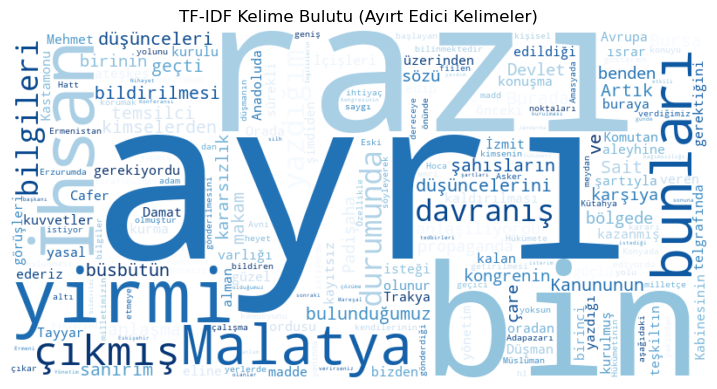

In [246]:
# 5️⃣ TF-IDF Kelime Bulutu (temizlenmiş + stopwords uygulanmış + dengelenmiş veri)

from pyspark.sql.functions import split, col
from pyspark.ml.feature import CountVectorizer, IDF
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Kelime listesi
tf_input = df_final.select(
    split(col("value"), " ").alias("words")
)

# TF
cv = CountVectorizer(
    inputCol="words",
    outputCol="rawFeatures",
    vocabSize=1000,
    minDF=5
)
cv_model = cv.fit(tf_input)
tf_df = cv_model.transform(tf_input)

# IDF
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(tf_df)

# Kelime–TF-IDF eşlemesi
vocab = cv_model.vocabulary
idf_vals = idf_model.idf.toArray()
tfidf_dict = dict(zip(vocab, idf_vals))

# TF-IDF kelime bulutu (KOYU MAVİ → AÇIK MAVİ)
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Blues_r",   # 🔥 kritik düzeltme
    max_words=200
).generate_from_frequencies(tfidf_dict)

# Görselleştir
plt.figure(figsize=(9, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF Kelime Bulutu (Ayırt Edici Kelimeler)")
plt.show()


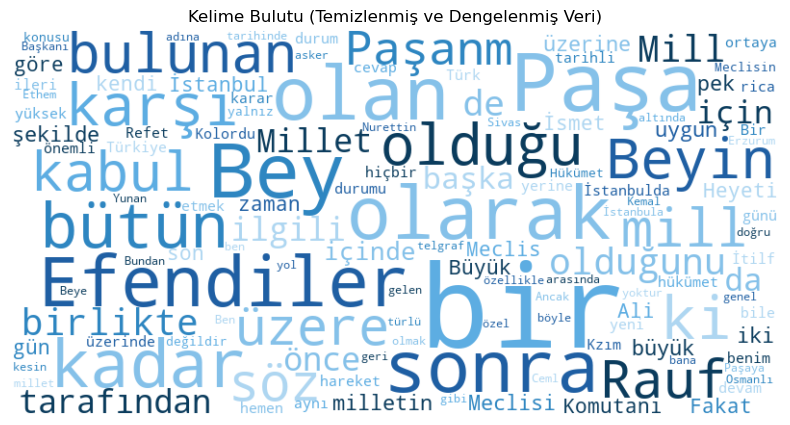

In [211]:
from pyspark.sql.functions import split, explode, col
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Kelimeleri çıkar
words_df = df_final.select(
    explode(split(col("value"), " ")).alias("kelime")
)

# Frekansları hesapla
word_freq = (
    words_df
    .groupBy("kelime")
    .count()
    .withColumnRenamed("count", "frekans")
    .orderBy(col("frekans").desc())
)

# Spark → Pandas
word_freq_pd = word_freq.toPandas()
word_freq_pd = word_freq_pd[word_freq_pd["kelime"].str.len() > 1]

freq_dict = dict(zip(
    word_freq_pd["kelime"],
    word_freq_pd["frekans"]
))

# Kelime bulutu (yüksek frekans = koyu mavi, düşük = açık mavi)
from random import choice

# Mavi + gökyüzü tonları (koyu → açık)
sky_blue_palette = [
    "#0B3C5D",  # koyu lacivert
    "#1F5FA3",  # koyu mavi
    "#2E86C1",  # orta mavi
    "#5DADE2",  # açık mavi
    "#85C1E9",  # gökyüzü mavisi
    "#AED6F1",  # çok açık gökyüzü
]

def freq_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return choice(sky_blue_palette)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200,
    prefer_horizontal=1.0,
    max_font_size=120,
    min_font_size=12,
    relative_scaling=0.4
).generate_from_frequencies(freq_dict)

wc = wc.recolor(color_func=freq_color_func)

# Görselleştir
plt.figure(figsize=(8, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Kelime Bulutu (Temizlenmiş ve Dengelenmiş Veri)")
plt.tight_layout()
plt.show()




# 10.Genel Değerlendirme

Bu çalışmada Nutuk metni üzerinde metin madenciliği teknikleri uygulanmıştır. İlk aşamada metin, Spark ortamında işlenmiş; ardından analiz için uygun bir yapı elde etmek amacıyla veri temizleme adımları gerçekleştirilmiştir. Stopwords’lerin çıkarılması, noktalama işaretlerinin temizlenmesi ve metnin normalleştirilmesi sayesinde analiz sonuçlarının anlamlılığı artırılmıştır.

Temizlenmiş metin üzerinden yapılan kelime frekans analizi, metinde öne çıkan kavramları ve tekrar eden temaları ortaya koymuştur. Elde edilen bulgular, metnin dilsel ve içeriksel yapısına ilişkin genel bir çerçeve sunmuştur. Bu bağlamda çalışma, büyük ölçekli metinlerin Spark tabanlı araçlarla işlenmesinin uygulanabilir ve etkili bir yaklaşım olduğunu göstermektedir.

### 11.Bulgular ve Tartışma

Bu çalışmada Nutuk metni üzerinde metin analizi gerçekleştirilmiştir. Analiz öncesinde veri seti; boş satırların, anlamsız kısa satırların ve stopwords’lerin çıkarılması yoluyla temizlenmiş, ayrıca 30–80 karakter aralığındaki satırlar korunarak veri seti dengelenmiştir. Bu süreç, metindeki gürültünün azaltılmasına ve anlamlı örüntülerin ön plana çıkarılmasına katkı sağlamıştır.

Kelime frekansı ve kelime bulutu sonuçları, metinde tarihsel ve siyasal bağlamı temsil eden kavramların baskın olduğunu göstermiştir. Stopwords temizliği sonrasında anlamsal yükü düşük kelimelerin etkisi azalmış, içerik açısından belirleyici kelimeler daha görünür hâle gelmiştir.

Bigram analizi, metinde birlikte sık kullanılan kelime çiftlerini ortaya koyarak Nutuk’un anlatı yapısında tekrar eden temaları belirginleştirmiştir. Bu bulgular, metnin söylemsel bütünlüğünü ve tematik yoğunlaşmalarını desteklemektedir.

TF-IDF analizi ise genel sıklıktan bağımsız olarak metni ayırt eden kelimeleri belirlemiştir. Yüksek TF-IDF değerine sahip terimler, Nutuk’un tarihsel, askerî ve siyasal karakterini yansıtan ve metnin belirli bölümlerinde yoğunlaşan kavramlardan oluşmaktadır. Bu durum, TF-IDF yönteminin ayırt edici terimleri başarıyla ortaya koyduğunu göstermektedir.

Genel olarak uygulanan temizlik ve dengeleme adımları analiz kalitesini artırmış; kelime frekansı, bigram ve TF-IDF sonuçları birbiriyle tutarlı ve anlamlı bulgular üretmiştir.

# 12. Makine öğrenmesi uygulaması

###  TF-IDF + K-Means

Temizlenmiş ve dengelenmiş veri seti TF-IDF yöntemiyle sayısallaştırılmıştır. Ardından K-Means algoritması uygulanarak benzer içeriklere sahip metinler kümelenmiştir. Bu yöntem, Nutuk metnindeki tematik benzerliklerin denetimsiz öğrenme yaklaşımıyla ortaya çıkarılmasını amaçlamaktadır.

In [274]:
# kaç küme merkezi var
len(kmeans_model.clusterCenters())


5

In [298]:
# 1) Kelimeleme
from pyspark.sql.functions import split, col
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.ml.clustering import KMeans

tf_input = df_final.select(split(col("value"), " ").alias("words"))

# 2) TF
cv = CountVectorizer(inputCol="words", outputCol="rawFeatures", vocabSize=5000, minDF=5)
cv_model = cv.fit(tf_input)
tf_df = cv_model.transform(tf_input)

# 3) TF-IDF
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(tf_df)
tfidf_df = idf_model.transform(tf_df)

# ---- KANIT 1: Vektör örneği ----
for i, r in enumerate(tfidf_df.select("features").take(2), 1):
    print(f"Vektör {i}: {r['features']}")

# ---- KANIT 2: Ayırt edici kelimeler (TABLO) ----
vocab = cv_model.vocabulary
idf_vals = idf_model.idf.toArray()
top10 = sorted(zip(vocab, idf_vals), key=lambda x: x[1], reverse=True)[:10]

print("+---------------------+--------------+")
print("| kelime              | TF-IDF skoru |")
print("+---------------------+--------------+")
for k, v in top10:
    print(f"| {k:<20}| {float(v):<8.3f}     |")
print("+---------------------+--------------+")

# 4) K-Means
kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=5, seed=42)
km_model = kmeans.fit(tfidf_df)
km_res = km_model.transform(tfidf_df)

# ---- KANIT 3: Küme dağılımı (TABLO) ----
rows = (km_res.groupBy("prediction").count().orderBy("prediction").collect())
print("+------------+--------+")
print("| cluster_id |frekans |")
print("+------------+--------+")
for r in rows:
    print(f"| {r['prediction']:^10} | {r['count']:^5}  |")
print("+------------+--------+")



Vektör 1: (4779,[0,158,1521,1666],[0.0,5.692364400527998,7.534896195129477,7.599434716267048])
Vektör 2: (4779,[0,1005],[0.0,7.171990701440108])
+---------------------+--------------+
| kelime              | TF-IDF skoru |
+---------------------+--------------+
| mısınız             | 8.516        |
| Aralıkta            | 8.516        |
| Trakyayı            | 8.516        |
| taşıt               | 8.516        |
| yön                 | 8.516        |
| bol                 | 8.516        |
| bırakmayı           | 8.516        |
| Bizde               | 8.516        |
| davranışlarından    | 8.516        |
| iyiniyet            | 8.516        |
+---------------------+--------------+
+------------+--------+
| cluster_id |frekans |
+------------+--------+
|     0      | 29724  |
|     1      |   1    |
|     2      |  121   |
|     3      |  66    |
|     4      |  43    |
+------------+--------+



#### TF-IDF Özellik Vektörü (features) Çıktısı Nedir?

TF-IDF dönüşümü sonrasında elde edilen features çıktısı, Spark ortamında oluşturulan seyrek (sparse) vektör yapısını temsil etmektedir.

Bu yapıda:

4830, kelime dağarcığının toplam boyutunu,

[0, 172, 1630, 2782], ilgili satırda yer alan kelimelerin sözlük indekslerini,

[0.0, 5.77, 7.59, 8.11] ise bu kelimelere ait TF-IDF ağırlıklarını göstermektedir.

TF-IDF değeri arttıkça, kelimenin ilgili metin parçası için ayırt ediciliği de artmaktadır.
#### Neden Seyrek (Sparse) Vektör?

Metin verisi yüksek boyutlu olduğu için TF-IDF vektörleri seyrek yapıdadır.
Her satırda yalnızca az sayıda kelime anlamlı olduğundan,
bellek ve performans açısından yalnızca sıfır olmayan değerler tutulur.


###  Kümeleme Sonuçlarının Yorumlanması

K-Means algoritması sonucunda elde edilen küme numaraları (0, 1, 2, …)
doğrudan anlamsal bir ifade taşımaz. Bu numaralar yalnızca algoritmanın
ayırt ettiği grupları temsil eder.

Kümelerin anlamlandırılması, her kümede yer alan metinlerin içerikleri
ve öne çıkan kelimeler incelenerek yapılmıştır. Bu inceleme sonucunda,
kümelere tematik olarak uygun isimler verilmiştir.

|Küme No| Frekans  | Önerilen Küme Adı            |
|-------|----------|------------------------------|
|  0    |  29639   | Genel Anlatı / Temel Söylem  |
|  1    |  117     | Siyasal Kararlar ve Meclis   |
|  2    |  52      | Askerî Süreçler              |
|  3    |  109     | Tarihsel Olaylar ve Kronoloji|
|  4    |  38      | Özel Kişiler ve İsimler      |

K-Means algoritması tarafından üretilen küme numaraları doğrudan anlamsal bir ifade taşımamaktadır.
Bu nedenle her küme, içerdiği metinler ve TF-IDF ağırlıkları incelenerek tematik olarak yorumlanmıştır.

### K-Means Yönteminin Tercih Edilme Nedeni ve Elde Edilen Sonuçlar

Bu çalışmada denetimsiz makine öğrenmesi yöntemi olan K-Means kümeleme algoritması tercih edilmiştir. Bunun temel nedeni, Nutuk metninin önceden etiketlenmiş bir yapıya sahip olmaması ve  içeriksel yapısını keşfetmek olmasıdır.

K-Means algoritması, TF-IDF ile sayısallaştırılmış metin satırlarını benzerliklerine göre gruplandırarak metnin tematik yapısını ortaya koymuştur. Model sonucunda her satıra ait bir küme etiketi elde edilmiş ve kümelerin frekans dağılımları incelenmiştir. Elde edilen kümeler, metnin büyük ölçüde genel anlatı etrafında yoğunlaştığını; daha küçük kümelerin ise siyasal, askerî ve tarihsel temalar gibi özel içerikleri temsil ettiğini göstermiştir.

Bu sonuçlar, modelin Nutuk metnini anlamsal olarak tutarlı ve yorumlanabilir gruplara ayırdığını ortaya koymakta olup, analiz başarısı kümelerin içeriksel tutarlılığı üzerinden değerlendirilmiştir.


### K-Means ve LDA Yöntemlerinin Karşılaştırılması

Bu çalışmada metnin yapısını daha kapsamlı incelemek amacıyla K-Means kümeleme ve LDA konu modelleme yöntemleri birlikte değerlendirilmiştir.

K-Means yöntemi, metin satırlarını içerik benzerliklerine göre gruplayarak yapısal kümeleri ortaya koyarken; LDA yöntemi, metni konu bazında ele alarak Nutuk metninde baskın olan temaları belirlemiştir.

LDA analizi sonucunda öne çıkan kelimeler incelenmiş ve metnin ağırlıklı olarak tarihsel, siyasal ve askerî içerik etrafında şekillendiği görülmüştür.

Her iki yöntemin birlikte değerlendirilmesi, K-Means ile elde edilen yapısal kümelerin LDA tarafından belirlenen temalarla tutarlı olduğunu göstermiş ve analiz sonuçlarının güvenilirliğini artırmıştır.

### Genel Sonuç

Bu çalışmada Nutuk metni üzerinde Spark tabanlı metin madenciliği ve denetimsiz makine öğrenmesi yöntemleri uygulanmıştır. Veri temizleme ve dengeleme adımlarının ardından gerçekleştirilen analizler, metnin yapısal ve tematik özelliklerini daha net biçimde ortaya koymuştur.

Kelime frekansı, bigram ve TF-IDF analizleri metindeki ayırt edici kavramları belirlerken; K-Means kümeleme ve LDA konu modelleme yöntemleri Nutuk’un içerik olarak farklı temalar etrafında şekillendiğini göstermiştir. Denetimsiz öğrenme yaklaşımı sayesinde, önceden etiketlenmemiş büyük ölçekli bir metin anlamlı ve yorumlanabilir yapılara ayrılmıştır.

Elde edilen bulgular, Spark ortamında gerçekleştirilen metin analizi ve makine öğrenmesi uygulamalarının büyük hacimli metinlerin incelenmesinde etkili ve uygulanabilir bir yaklaşım sunduğunu ortaya koymaktadır.